In [10]:
#environment setup
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.nn as nn
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

In [11]:
#load all the csv files
users = pd.read_csv('users.csv')
events = pd.read_csv('ad_events.csv')
campaigns = pd.read_csv('campaigns.csv')
ads = pd.read_csv('ads.csv')

print(f"Events: {len(events):,}")
print(events['event_type'].value_counts())

Events: 235,299
event_type
Impression    199880
Click          23514
Like            7124
Comment         2444
Purchase        1197
Share           1139
Name: count, dtype: int64


In [12]:
from pandas.core import groupby
#engagement score
weights = {
    'Impression': 0,
    'Click': 1,
    'Like': 2,
    'Comment': 2,
    'Share': 3,
    'Purchase': 5,
}

events['engagement_weight'] = events['event_type'].map(weights)

#group actions by user and ad ids (one user can have multiple interaction with one ad)
engagement = (events
    .groupby(['ad_id', 'user_id'])['engagement_weight'].sum().reset_index().rename(columns = {'engagement_weight': 'engagement_score'})
)

print(engagement.shape)
print(engagement['engagement_score'].describe())



(221648, 3)
count    221648.000000
mean          0.234841
std           0.640463
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           7.000000
Name: engagement_score, dtype: float64


In [13]:
#merge engagements with ads
df = engagement.merge(ads, on = 'ad_id')

#merge engagements with campaigns
df = df.merge(campaigns[['campaign_id', 'total_budget', 'duration_days']], on = 'campaign_id')

#merge with user info
df = df.merge(users[['user_id', 'user_age', 'user_gender']], on = 'user_id')

print(df.shape)
print(df.head())

(223699, 13)
   ad_id user_id  engagement_score  campaign_id ad_platform ad_type  \
0      1   00336               0.0           28    Facebook   Video   
1      1   004a5               0.0           28    Facebook   Video   
2      1   011b8               2.0           28    Facebook   Video   
3      1   01da6               0.0           28    Facebook   Video   
4      1   0232d               0.0           28    Facebook   Video   

  target_gender target_age_group target_interests  total_budget  \
0        Female            35-44  art, technology      32844.79   
1        Female            35-44  art, technology      32844.79   
2        Female            35-44  art, technology      32844.79   
3        Female            35-44  art, technology      32844.79   
4        Female            35-44  art, technology      32844.79   

   duration_days  user_age user_gender  
0             52        25      Female  
1             52        27        Male  
2             52        23        

In [14]:
#encode categoricals
le = LabelEncoder()

#converting strings into numbers
cat_cols = ['ad_platform', 'ad_type', 'target_gender', 'target_age_group', 'user_gender']

for col in cat_cols:
  df[col] = le.fit_transform(df[col].astype(str))

print(df[cat_cols].head())

   ad_platform  ad_type  target_gender  target_age_group  user_gender
0            0        3              1                 2            0
1            0        3              1                 2            1
2            0        3              1                 2            1
3            0        3              1                 2            0
4            0        3              1                 2            1


In [17]:
feature_cols = [
    'user_age', 'user_gender', 'ad_platform', 'ad_type', 'target_gender', 'total_budget', 'duration_days'
]

x = df[feature_cols].values
y= df['engagement_score'].values.reshape(-1,1)

#scale
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x = scaler_x.fit_transform(x)
y = scaler_y.fit_transform(y)

print(f"X Shape: {x.shape}, Y Shape: {y.shape}")

X Shape: (223699, 7), Y Shape: (223699, 1)


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

#convert to tensors
x_train = torch.FloatTensor(x_train)
x_test = torch.FloatTensor(x_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

print(f"Train: {x_train.shape}, Test: {x_test.shape}")

Train: torch.Size([178959, 7]), Test: torch.Size([44740, 7])


In [19]:
#building the model
class AdEngagementScore(nn.Module):
  def __init__(self, input_size):
    super().__init__()
    self.network = nn.Sequential(
        nn.Linear(input_size, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32,16),
        nn.ReLU(),
        nn.Linear(16,1)
    )
  #forward pass
  def forward(self,x):
    return self.network(x)

model = AdEngagementScore(input_size = len(feature_cols))
print(model)

AdEngagementScore(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ReLU()
    (6): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [23]:
#Train the model
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001)

epochs = 200
train_losses, test_losses = [], []

for epoch in range(epochs):
  model.train()
  preds = model(x_train)
  loss  = loss_fn(preds, y_train)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  model.eval()
  with torch.no_grad():
    test_preds = model(x_test)
    test_loss = loss_fn(test_preds, y_test)

  train_losses.append(loss.item())
  test_losses.append(test_loss.item())

  if epoch%20 == 0:
    print(f"Epoch: {epoch:3d} | Train: {loss.item():.4f} | Test: {test_loss.item():.4f}")

Epoch:   0 | Train: 1.0045 | Test: 0.9804
Epoch:  20 | Train: 1.0041 | Test: 0.9806
Epoch:  40 | Train: 1.0037 | Test: 0.9808
Epoch:  60 | Train: 1.0032 | Test: 0.9811
Epoch:  80 | Train: 1.0026 | Test: 0.9815
Epoch: 100 | Train: 1.0020 | Test: 0.9821
Epoch: 120 | Train: 1.0014 | Test: 0.9825
Epoch: 140 | Train: 1.0008 | Test: 0.9830
Epoch: 160 | Train: 1.0003 | Test: 0.9834
Epoch: 180 | Train: 0.9999 | Test: 0.9838


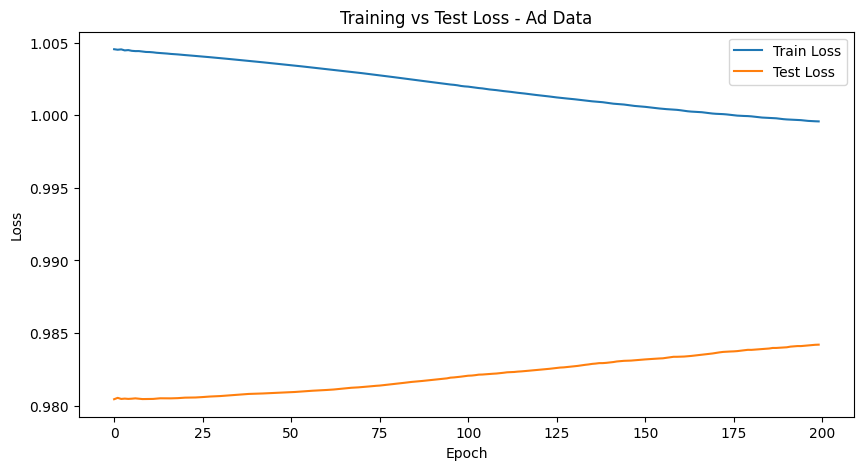

Final Train Loss: 0.9996
Final Test Loss: 0.984204


In [24]:
#plotting a graph
plt.figure(figsize = (10, 5))
plt.plot(train_losses, label = "Train Loss")
plt.plot(test_losses, label = "Test Loss")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Test Loss - Ad Data')
plt.legend()
plt.show()

print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Final Test Loss: {test_losses[-1]:4f}")